<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/InfinityTensor_3x3_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Symbolic Emission Tensor K^∞_{μν} = E^∞ - Φ^∞:


⎡h̅⋅ν₀₀ - φ₀₀  h̅⋅ν₀₁ - φ₀₁  h̅⋅ν₀₂ - φ₀₂⎤
⎢                                     ⎥
⎢h̅⋅ν₁₀ - φ₁₀  h̅⋅ν₁₁ - φ₁₁  h̅⋅ν₁₂ - φ₁₂⎥
⎢                                     ⎥
⎣h̅⋅ν₂₀ - φ₂₀  h̅⋅ν₂₁ - φ₂₁  h̅⋅ν₂₂ - φ₂₂⎦

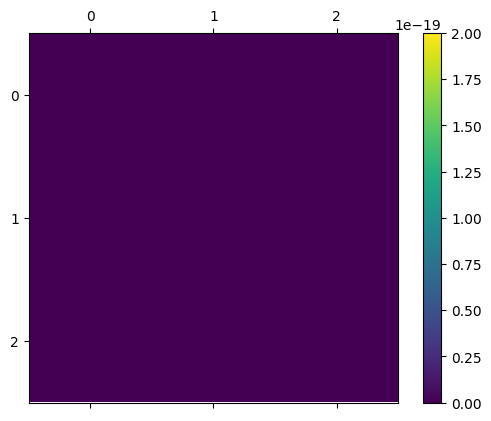

In [1]:

# 📘 Infinity Tensor Photoelectric Simulation — Extended (3x3 + Animation)

!pip install sympy matplotlib numpy --quiet

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, simplify, init_printing
init_printing()

hbar = symbols('hbar')
nu = symbols('nu_00 nu_01 nu_02 nu_10 nu_11 nu_12 nu_20 nu_21 nu_22')
phi = symbols('phi_00 phi_01 phi_02 phi_10 phi_11 phi_12 phi_20 phi_21 phi_22')

Omega_inf = Matrix(3, 3, nu)
Phi_inf = Matrix(3, 3, phi)
E_inf = hbar * Omega_inf
K_inf = E_inf - Phi_inf

print("Symbolic Emission Tensor K^∞_{μν} = E^∞ - Φ^∞:")
display(K_inf)

hbar_val = 1.05e-34
phi_numeric = np.array([
    [2.0e-19, 2.2e-19, 2.4e-19],
    [2.6e-19, 2.8e-19, 3.0e-19],
    [3.2e-19, 3.4e-19, 3.6e-19]
])
base_nu = np.array([
    [1.1e15, 1.3e15, 1.5e15],
    [1.7e15, 1.9e15, 2.1e15],
    [2.3e15, 2.5e15, 2.7e15]
])

fig, ax = plt.subplots()
cax = ax.matshow(np.zeros((3, 3)), cmap='viridis', vmin=0, vmax=2e-19)
fig.colorbar(cax)

def update(frame):
    nu_factor = 0.5 + frame * 0.05
    nu_matrix = nu_factor * base_nu
    e_matrix = hbar_val * nu_matrix
    k_matrix = e_matrix - phi_numeric
    cax.set_array(k_matrix)
    ax.set_title(f"Emission Tensor (ν scale = {nu_factor:.2f})")
    return [cax]

ani = FuncAnimation(fig, update, frames=30, interval=300, blit=False)
plt.show()
